# C1 | Respiratory emergency visits in Chile, 2020-2024

**Question.** How did the volume and share of recorded respiratory emergency visits change by week and care setting, and what historical timing information can support a *proposed* Winter Campaign monitoring decision? One source row is an aggregate facility/date/cause record, not a patient. This notebook starts from the included uncleaned reduced input; it needs no full annual download. Run every cell in order and save outputs. The report PDF contains the full argument, sources, Process record and limitations.

**W1-to-C1 correction.** W1 reported five-year aggregates but packaged only selected 2023-2024 peak weeks as reduced emergency input. C1 includes every date from the five local annual archives for cause IDs 1 and 2. The change followed a teammate's internal review; W1 received full marks and no specific post-W1 instructor advice has been reported. We also resolve two identical 2023 duplicate rows and derive Sunday week starts from dates so annual week labels cannot merge disjoint boundary weeks.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd().parent
assert (ROOT / 'data/input/emergency_id1_id2_all_dates_2020_2024.csv.gz').exists()
FIG = ROOT / 'analysis/figures'
FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Python', sys.version.split()[0], '| pandas', pd.__version__, '| NumPy', np.__version__,
      '| matplotlib', matplotlib.__version__)
print('Package:', ROOT.name)

Python 3.13.15 | pandas 3.0.1 | NumPy 2.4.3 | matplotlib 3.10.8
Package: GROUP_02_C1


## 1. Source structure and selected-row profile

The five annual DEIS archives, official URLs and SHA-256 fingerprints are recorded in `data/source_manifest.csv`. The included input preserves uncleaned rows for `IdCausa=1` (all visits) and `IdCausa=2` (respiratory visits), as defined in the included DEIS dictionary. `Total` and five age columns are counts. Recorded zeros are meaningful and remain in the case. Source data cover public-network activity and do not identify patients or all care in Chile.

In [2]:
raw = pd.read_csv(ROOT / 'data/input/emergency_id1_id2_all_dates_2020_2024.csv.gz',
                  dtype={'IdEstablecimiento': 'string'}, low_memory=False)
KEY = ['source_year', 'IdEstablecimiento', 'fecha', 'IdCausa']
AGES = ['Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas']
assert len(raw) == 2_169_824
assert set(raw.source_year.unique()) == set(range(2020, 2025))
assert set(raw.IdCausa.unique()) == {1, 2}
profile = raw.groupby(['source_year', 'IdCausa']).agg(
    rows=('Total', 'size'), facilities=('IdEstablecimiento', 'nunique'),
    dates=('fecha', 'nunique'), recorded_zero_rows=('Total', lambda s: int(s.eq(0).sum()))
).reset_index()
display(profile)
print('Columns:', ', '.join(raw.columns))
print('Null cells in key, measures and type:', int(raw[KEY + ['Total', *AGES,
      'GLOSATIPOESTABLECIMIENTO']].isna().sum().sum()))

,source_year,IdCausa,rows,facilities,dates,recorded_zero_rows
0,2020,1,194541,607,366,3839
1,2020,2,194541,607,366,38434
2,2021,1,220406,635,365,8163
3,2021,2,220406,635,365,46616
4,2022,1,223158,638,365,8425
5,2022,2,223158,638,365,21424
6,2023,1,222477,642,365,7357
7,2023,2,222477,642,365,15157
8,2024,1,224330,640,366,7640
9,2024,2,224330,640,366,14800


Columns: source_year, IdEstablecimiento, IdCausa, Total, Menores_1, De_1_a_4, De_5_a_14, De_15_a_64, De_65_y_mas, fecha, semana, GLOSATIPOESTABLECIMIENTO
Null cells in key, measures and type: 0


## 2. Quality and preparation decisions

The candidate source key is `(year, facility ID, date, cause ID)`. Check duplicates, valid dates, nonnegative counts, age-sum arithmetic, and cause pairing. Keep recorded zero counts. A duplicated key is removed only after verifying that the entire source rows are identical. This changes 2023's all-visit count by 13 relative to W1's raw total; respiratory visits do not change.

In [3]:
parsed = pd.to_datetime(raw.fecha, format='%d/%m/%Y', errors='coerce')
duplicates = raw.loc[raw.duplicated(KEY, keep=False)].sort_values(KEY)
assert len(duplicates) == 4
assert all(len(g.drop_duplicates()) == 1 for _, g in duplicates.groupby(KEY))
assert parsed.notna().all()
assert parsed.dt.year.eq(raw.source_year).all()
assert raw.semana.between(1, 53).all()
assert raw[['Total', *AGES]].ge(0).all().all()
assert raw.Total.eq(raw[AGES].sum(axis=1)).all()
clean = raw.drop_duplicates(KEY, keep='first').copy()
clean['date'] = pd.to_datetime(clean.fecha, format='%d/%m/%Y')
clean['week_start'] = clean.date - pd.to_timedelta((clean.date.dt.dayofweek + 1) % 7, unit='D')
before = raw.groupby(['source_year', 'IdCausa']).Total.sum().unstack()
after = clean.groupby(['source_year', 'IdCausa']).Total.sum().unstack()
impact = pd.DataFrame({'all_before': before[1], 'all_after': after[1],
                       'resp_before': before[2], 'resp_after': after[2]})
impact['all_removed'] = impact.all_before - impact.all_after
impact['resp_removed'] = impact.resp_before - impact.resp_after
display(duplicates)
display(impact)

,source_year,IdEstablecimiento,IdCausa,Total,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,De_65_y_mas,fecha,semana,GLOSATIPOESTABLECIMIENTO
1462024,2023,08-105,1,13,0,0,0,13,0,10/01/2023,2,Hospital
1462025,2023,08-105,1,13,0,0,0,13,0,10/01/2023,2,Hospital
1462091,2023,08-105,2,0,0,0,0,0,0,10/01/2023,2,Hospital
1462092,2023,08-105,2,0,0,0,0,0,0,10/01/2023,2,Hospital


,all_before,all_after,resp_before,resp_after,all_removed,resp_removed
source_year,,,,,,
2020,11382496,11382496,1223447,1223447,0,0
2021,13851594,13851594,1381568,1381568,0,0
2022,19491232,19491232,4812171,4812171,0,0
2023,19194240,19194227,5557541,5557541,13,0
2024,19436048,19436048,5541628,5541628,0,0


In [4]:
pairs = clean.pivot(index=['source_year', 'IdEstablecimiento', 'fecha'],
                    columns='IdCausa', values='Total')
assert pairs[[1, 2]].notna().all().all()
assert pairs[2].le(pairs[1]).all()
collisions = (clean.groupby(['source_year', 'semana']).week_start.nunique()
              .loc[lambda s: s.gt(1)].reset_index(name='distinct_week_starts'))
print(f'Paired facility dates: {len(pairs):,}; missing cause rows: 0; respiratory > all: 0')
print('Source year/week labels mapping to multiple actual weeks:')
display(collisions)

Paired facility dates: 1,084,911; missing cause rows: 0; respiratory > all: 0
Source year/week labels mapping to multiple actual weeks:


,source_year,semana,distinct_week_starts
0,2022,52,2
1,2023,1,2
2,2024,1,2


## 3. Annual demand composition

Respiratory share = `100 × respiratory visits (ID 2) / all emergency visits (ID 1)` in the same source year. The denominator is consultations, not residents. Counts and shares here are descriptive observations; the files do not explain why years differ.

,year,all_emergency_visits,respiratory_visits,respiratory_share_pct
0,2020,11382496,1223447,10.75
1,2021,13851594,1381568,9.97
2,2022,19491232,4812171,24.69
3,2023,19194227,5557541,28.95
4,2024,19436048,5541628,28.51


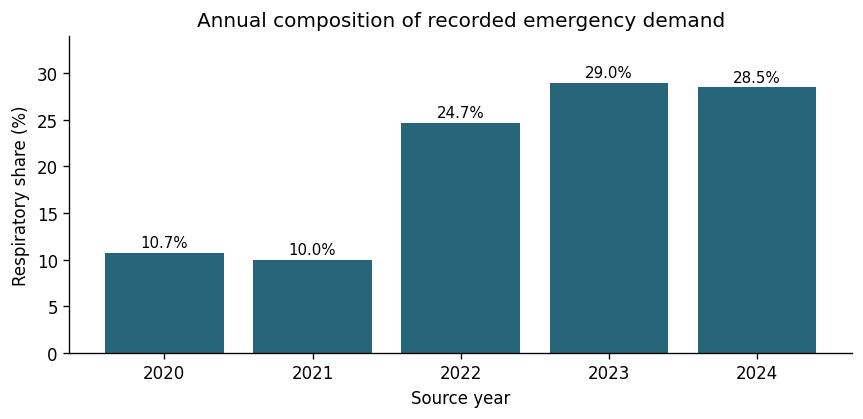

In [5]:
annual = after.rename(columns={1: 'all_emergency_visits', 2: 'respiratory_visits'}).reset_index().rename(columns={'source_year': 'year'})
annual.columns.name = None
annual['respiratory_share_pct'] = 100 * annual.respiratory_visits / annual.all_emergency_visits
saved_annual = pd.read_csv(ROOT / 'data/processed/annual_summary.csv')
pd.testing.assert_frame_equal(annual, saved_annual, check_exact=False, rtol=1e-12)
display(annual.assign(respiratory_share_pct=annual.respiratory_share_pct.round(2)))
fig, ax = plt.subplots(figsize=(7.3, 3.6))
ax.bar(annual.year.astype(str), annual.respiratory_share_pct, color='#27667a')
ax.set(ylabel='Respiratory share (%)', xlabel='Source year',
       title='Annual composition of recorded emergency demand')
ax.set_ylim(0, 34)
for i, value in enumerate(annual.respiratory_share_pct):
    ax.text(i, value + 0.6, f'{value:.1f}%', ha='center', fontsize=9)
fig.tight_layout(); fig.savefig(FIG / 'annual_respiratory_share.png', bbox_inches='tight'); plt.show()

## 4. Complete-week timing and peaks

Weeks run Sunday through Saturday, derived from `fecha`. The first and last series weeks include only four and three source days, so peak comparisons exclude them. `reporting_year` is the year of the week-ending Saturday. A peak in these archives is historical evidence, not a forecast or a causal effect.

In [6]:
week_counts = clean.groupby(['week_start', 'IdCausa']).Total.sum().unstack().rename(
    columns={1: 'all_emergency_visits', 2: 'respiratory_visits'}).reset_index()
week_counts['week_end'] = week_counts.week_start + pd.Timedelta(days=6)
week_counts['reporting_year'] = week_counts.week_end.dt.year
days = clean[['week_start', 'date']].drop_duplicates().groupby('week_start').date.nunique()
week_counts['observed_days'] = week_counts.week_start.map(days)
week_counts['complete_week'] = week_counts.observed_days.eq(7)
week_counts['respiratory_share_pct'] = 100 * week_counts.respiratory_visits / week_counts.all_emergency_visits
assert len(week_counts) == 262 and int(week_counts.complete_week.sum()) == 260
saved_weekly = pd.read_csv(ROOT / 'data/processed/weekly_national_2020_2024.csv',
                           parse_dates=['week_start', 'week_end'])
for column in ['all_emergency_visits', 'respiratory_visits', 'respiratory_share_pct']:
    np.testing.assert_allclose(week_counts[column], saved_weekly[column], rtol=1e-12)
complete = week_counts.loc[week_counts.complete_week]
peaks = complete.loc[complete.groupby('reporting_year').respiratory_visits.idxmax(),
                     ['reporting_year', 'week_start', 'week_end', 'respiratory_visits', 'respiratory_share_pct']]
display(peaks.assign(week_start=peaks.week_start.dt.strftime('%d %b %Y'),
                     week_end=peaks.week_end.dt.strftime('%d %b %Y'),
                     respiratory_share_pct=peaks.respiratory_share_pct.round(2)))

IdCausa,reporting_year,week_start,week_end,respiratory_visits,respiratory_share_pct
11,2020,15 Mar 2020,21 Mar 2020,103314,38.04
98,2021,14 Nov 2021,20 Nov 2021,47697,14.61
148,2022,30 Oct 2022,05 Nov 2022,161522,36.00
176,2023,14 May 2023,20 May 2023,189297,41.66
228,2024,12 May 2024,18 May 2024,203353,45.56


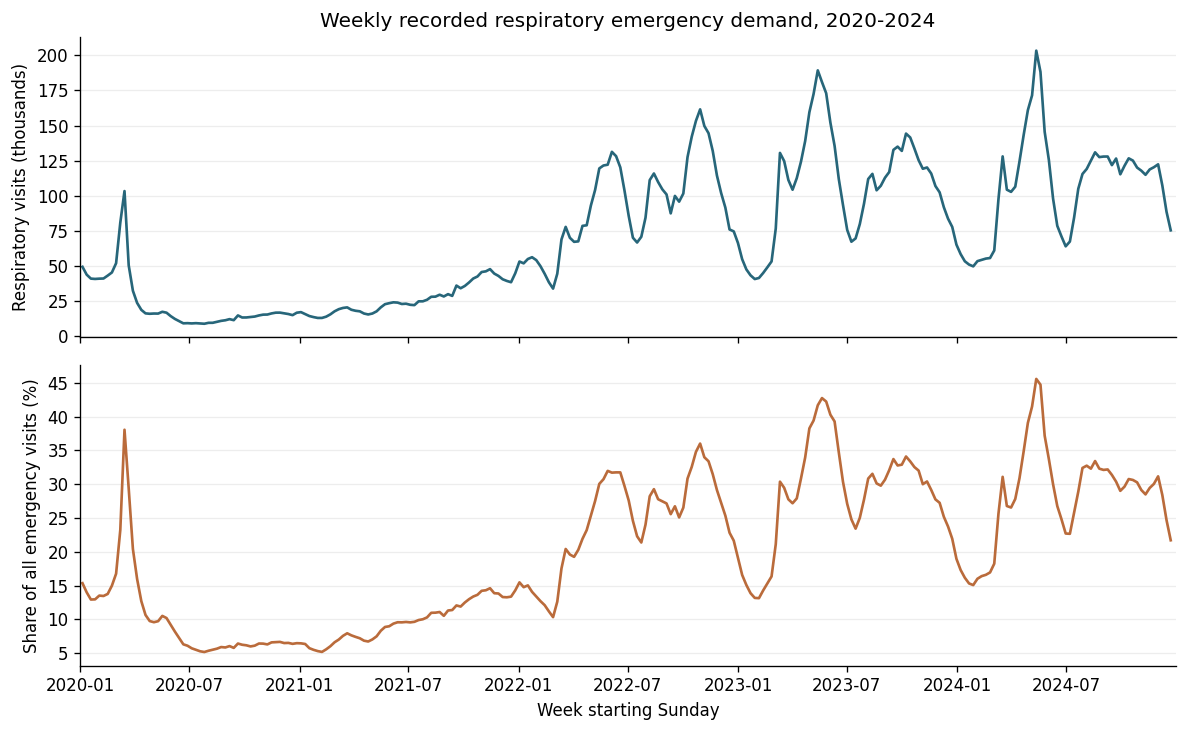

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True)
axes[0].plot(complete.week_start, complete.respiratory_visits / 1000, color='#27667a', lw=1.6)
axes[0].set(ylabel='Respiratory visits (thousands)', title='Weekly recorded respiratory emergency demand, 2020-2024')
axes[1].plot(complete.week_start, complete.respiratory_share_pct, color='#ba6b3b', lw=1.6)
axes[1].set(ylabel='Share of all emergency visits (%)', xlabel='Week starting Sunday')
for ax in axes: ax.grid(axis='y', alpha=.22)
axes[1].set_xlim(pd.Timestamp('2020-01-01'), pd.Timestamp('2024-12-31'))
fig.tight_layout(); fig.savefig(FIG / 'weekly_volume_and_share.png', bbox_inches='tight'); plt.show()

## 4b. Full EDA: Distributions, densities, and cross-group correlations

As required for the full EDA, we examine the parametric and nonparametric distribution of weekly respiratory volumes and shares, contrasting the pandemic suppression regime (2020–2021) with the post-pandemic rebound (2022–2024). We also compute both Pearson (linear) and Spearman (rank) correlation matrices across age bands and evaluate the demand coupling between primary emergency care (SAPU, SAR, SUR) and hospitals.

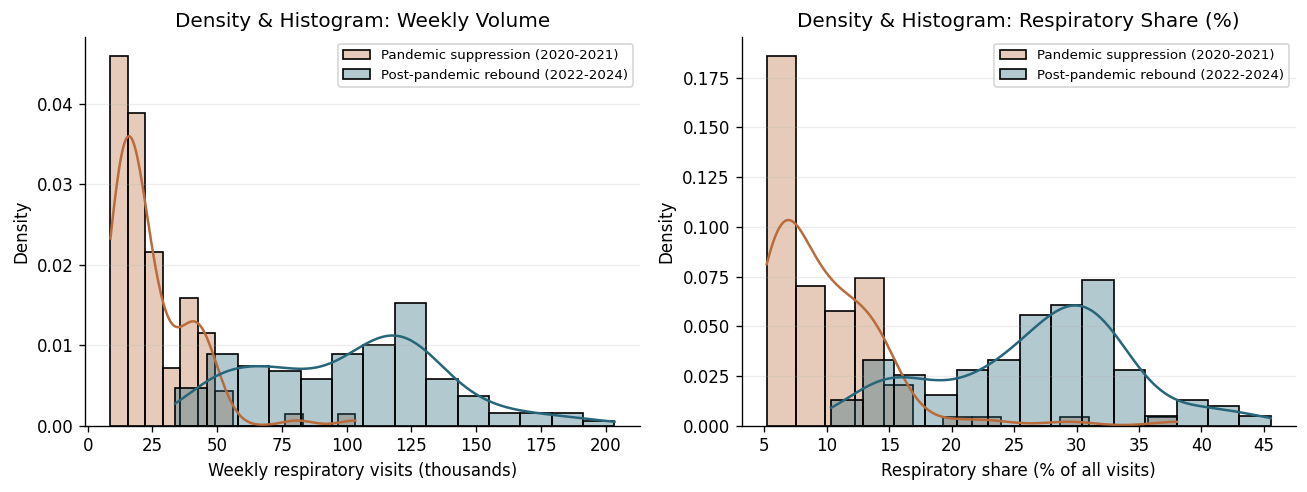

In [8]:
# 1. Histograms and Kernel Density Estimation (KDE)
complete_eda = complete.copy()
complete_eda['regime'] = np.where(complete_eda.reporting_year.isin([2020, 2021]),
                                  'Pandemic suppression (2020-2021)',
                                  'Post-pandemic rebound (2022-2024)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for regime, color in [('Pandemic suppression (2020-2021)', '#ba6b3b'),
                      ('Post-pandemic rebound (2022-2024)', '#27667a')]:
    sub = complete_eda.loc[complete_eda.regime.eq(regime)]
    sns.histplot(sub['respiratory_visits'] / 1000, kde=True, ax=axes[0], color=color,
                 label=regime, stat='density', bins=14, alpha=0.35)
    sns.histplot(sub['respiratory_share_pct'], kde=True, ax=axes[1], color=color,
                 label=regime, stat='density', bins=14, alpha=0.35)

axes[0].set(title='Density & Histogram: Weekly Volume',
            xlabel='Weekly respiratory visits (thousands)', ylabel='Density')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.22)

axes[1].set(title='Density & Histogram: Respiratory Share (%)',
            xlabel='Respiratory share (% of all visits)', ylabel='Density')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.22)

fig.tight_layout()
fig.savefig(FIG / 'eda_distributions_kde.png', bbox_inches='tight')
plt.show()

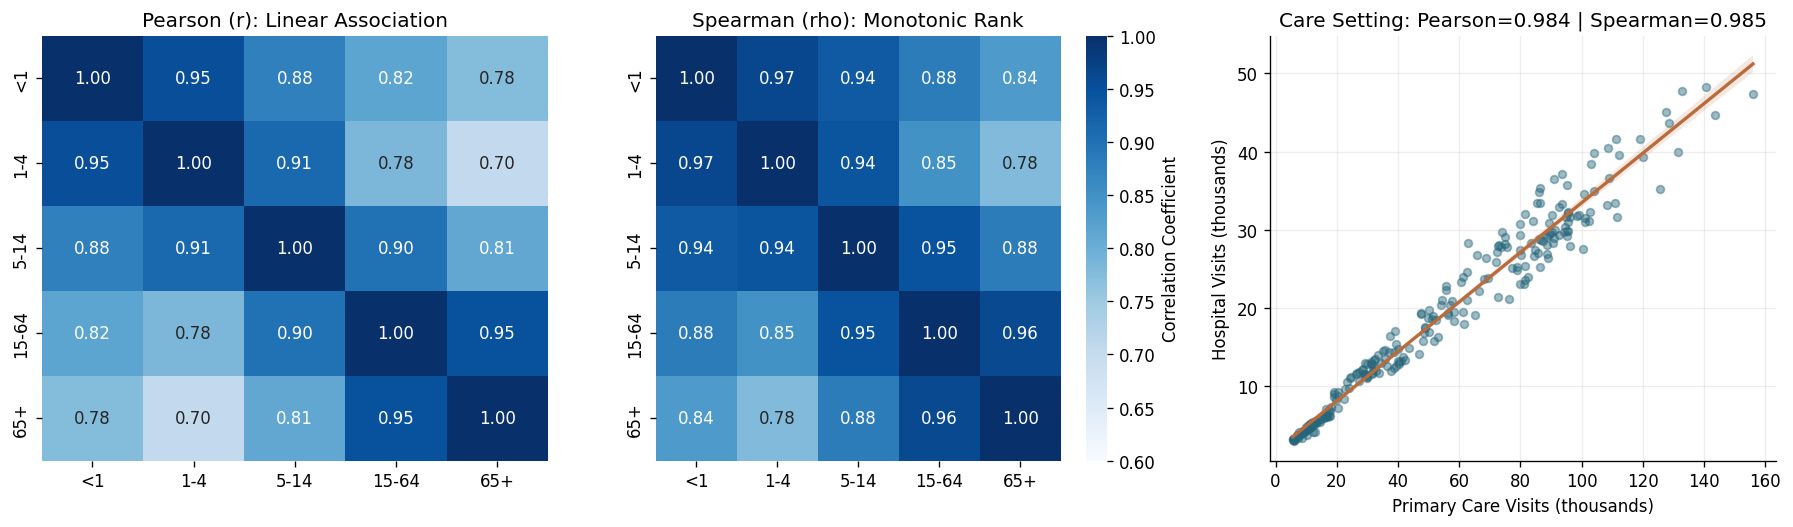

=== STATISTICAL COMPARISON: SPEARMAN MINUS PEARSON (rho - r) ===


,<1,1-4,5-14,15-64,65+
<1,0.000,0.012,0.059,0.066,0.060
1-4,0.012,0.000,0.030,0.066,0.074
5-14,0.059,0.030,0.000,0.048,0.073
15-64,0.066,0.066,0.048,0.000,0.013
65+,0.060,0.074,0.073,0.013,0.000


Primary Care vs. Hospital Coupling: Pearson r = 0.9835, Spearman rho = 0.9848
Weekly Volume vs. Respiratory Share: Pearson r = 0.9797, Spearman rho = 0.9819


In [9]:
# 2. Statistical Correlation Analysis: Pearson (Linear) vs. Spearman (Rank/Monotonic)
resp_rows = clean.loc[clean.IdCausa.eq(2)]
age_map = {'Menores_1': '<1', 'De_1_a_4': '1-4', 'De_5_a_14': '5-14',
           'De_15_a_64': '15-64', 'De_65_y_mas': '65+'}
weekly_age = resp_rows.groupby('week_start')[list(age_map.keys())].sum().rename(columns=age_map)

# Compute both Pearson (linear) and Spearman (rank)
pearson_age = weekly_age.corr(method='pearson')
spearman_age = weekly_age.corr(method='spearman')
diff_age = spearman_age - pearson_age

# Care-setting coupling
resp_setting = resp_rows.groupby(['week_start', 'GLOSATIPOESTABLECIMIENTO']).Total.sum().unstack(fill_value=0)
hosp_cols = [c for c in resp_setting.columns if 'Hospital' in c]
primary_cols = [c for c in resp_setting.columns if any(p in c for p in ['SAPU', 'SAR', 'SUR'])]
weekly_setting = pd.DataFrame({
    'Hospitals': resp_setting[hosp_cols].sum(axis=1) / 1000,
    'Primary Care (SAPU/SAR/SUR)': resp_setting[primary_cols].sum(axis=1) / 1000
})
p_setting = float(weekly_setting.corr(method='pearson').iloc[0, 1])
s_setting = float(weekly_setting.corr(method='spearman').iloc[0, 1])

# Volume vs share
p_vol_share = float(complete[['respiratory_visits', 'respiratory_share_pct']].corr(method='pearson').iloc[0, 1])
s_vol_share = float(complete[['respiratory_visits', 'respiratory_share_pct']].corr(method='spearman').iloc[0, 1])

# 3-Panel Figure comparing Pearson, Spearman, and Care-setting Coupling
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.heatmap(pearson_age, annot=True, fmt='.2f', cmap='Blues', vmin=0.6, vmax=1.0, ax=axes[0],
            cbar=False)
axes[0].set_title('Pearson (r): Linear Association')

sns.heatmap(spearman_age, annot=True, fmt='.2f', cmap='Blues', vmin=0.6, vmax=1.0, ax=axes[1],
            cbar_kws={'label': 'Correlation Coefficient'})
axes[1].set_title('Spearman (rho): Monotonic Rank')

sns.regplot(data=weekly_setting, x='Primary Care (SAPU/SAR/SUR)', y='Hospitals', ax=axes[2],
            color='#27667a', scatter_kws={'alpha': 0.45, 's': 22}, line_kws={'color': '#ba6b3b', 'lw': 2})
axes[2].set_title(f'Care Setting: Pearson={p_setting:.3f} | Spearman={s_setting:.3f}')
axes[2].set_xlabel('Primary Care Visits (thousands)')
axes[2].set_ylabel('Hospital Visits (thousands)')
axes[2].grid(True, alpha=0.22)

fig.tight_layout()
fig.savefig(FIG / 'eda_correlation_analysis.png', bbox_inches='tight')
plt.show()

print('=== STATISTICAL COMPARISON: SPEARMAN MINUS PEARSON (rho - r) ===')
display(diff_age.round(3))
print(f'Primary Care vs. Hospital Coupling: Pearson r = {p_setting:.4f}, Spearman rho = {s_setting:.4f}')
print(f'Weekly Volume vs. Respiratory Share: Pearson r = {p_vol_share:.4f}, Spearman rho = {s_vol_share:.4f}')

### Statistical Interpretation: Pearson vs. Spearman under Heavy-Tailed Winter Surges

1. **Parametric Assumptions vs. Rank Robustness:** Pearson correlation evaluates strictly linear co-variation under the assumption of bivariate normality and is sensitive to extreme seasonal surge tails. Spearman rank correlation evaluates monotonic association, making no parametric distribution assumptions and remaining invariant to monotonic non-linear transformations.
2. **Empirical Differences Across Age Cohorts:** Spearman rank correlations across weekly age volumes are systematically higher than Pearson correlations ($\Delta = +0.012$ to $+0.074$). For instance, the association between infants (<1) and seniors (65+) increases from $r = 0.775$ (Pearson) to $\rho = 0.835$ (Spearman). This reflects the fact that while viral transmission waves display different slopes and onset timings across cohorts (e.g. sharp early RSV surges in infants vs. delayed influenza peaks in older adults), the week-by-week severity hierarchy is strongly preserved monotonically.
3. **Care-Setting Coupling:** Both Pearson ($r = 0.9835$) and Spearman ($\rho = 0.9848$) are nearly identical and close to 1.0, proving that the co-movement between primary emergency care (SAPU/SAR/SUR) and hospital emergency departments is not an artifact of a few extreme peak weeks, but a persistent operational coupling across all 260 complete weeks.

## 5. Age and care-setting composition

These are shares of **respiratory visits**. They do not describe unique people, severity or service capacity. Source facility type is a place of care; it is not the patient's home municipality. The national question does not require an external geographic join, so none is used.

,Menores_1,De_1_a_4,De_5_a_14,De_15_a_64,De_65_y_mas
year,,,,,
2020,5.73,12.37,11.95,57.64,12.31
2021,6.83,20.48,13.79,49.44,9.47
2022,5.56,19.83,25.31,41.96,7.33
2023,5.19,15.79,25.36,44.85,8.81
2024,3.89,13.11,23.72,49.47,9.81


GLOSATIPOESTABLECIMIENTO,CEAR,Hospital,SAPU,SAR,SUR
source_year,,,,,
2020,0.46,28.46,48.09,19.36,3.63
2021,0.72,29.39,40.91,23.33,5.65
2022,0.49,27.73,41.94,23.12,6.72
2023,0.12,24.61,43.34,24.50,7.43
2024,0.00,24.13,42.28,25.76,7.82


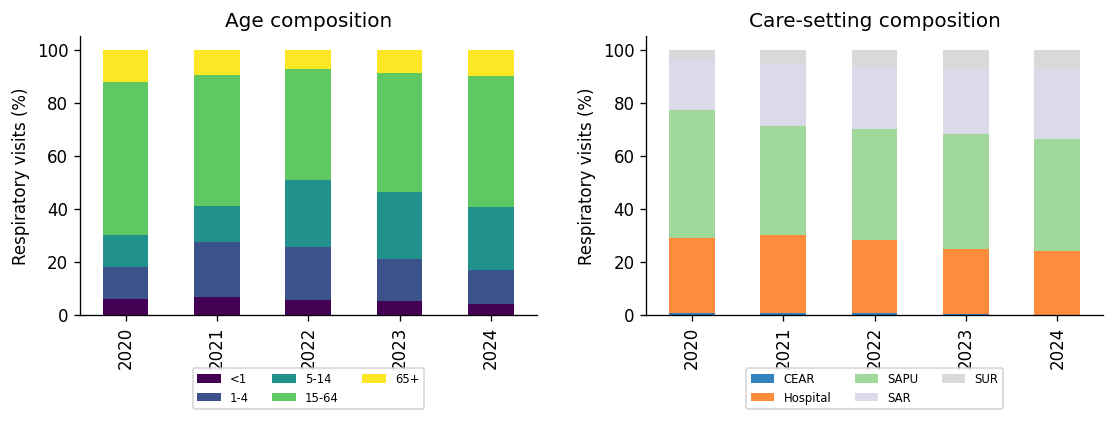

In [10]:
resp = clean.loc[clean.IdCausa.eq(2)]
age = resp.groupby('source_year')[AGES].sum()
age_share = 100 * age.div(age.sum(axis=1), axis=0)
age_share.index.name = 'year'
display(age_share.round(2))
type_counts = resp.groupby(['source_year', 'GLOSATIPOESTABLECIMIENTO']).Total.sum().unstack(fill_value=0)
type_share = 100 * type_counts.div(type_counts.sum(axis=1), axis=0)
display(type_share.round(2))
assert int(age.to_numpy().sum()) == int(annual.respiratory_visits.sum())
assert int(type_counts.to_numpy().sum()) == int(annual.respiratory_visits.sum())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
age_share.rename(columns={'Menores_1': '<1', 'De_1_a_4': '1-4', 'De_5_a_14': '5-14',
                          'De_15_a_64': '15-64', 'De_65_y_mas': '65+'}).plot.bar(
    stacked=True, ax=axes[0], colormap='viridis', legend=True)
axes[0].set(title='Age composition', ylabel='Respiratory visits (%)', xlabel='')
type_share.plot.bar(stacked=True, ax=axes[1], colormap='tab20c', legend=True)
axes[1].set(title='Care-setting composition', ylabel='Respiratory visits (%)', xlabel='')
for ax in axes: ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(.5, -.17), ncol=3)
fig.subplots_adjust(bottom=.30, wspace=.24)
fig.savefig(FIG / 'age_and_facility_mix.png', bbox_inches='tight')
plt.show()

## 6. Reporting coverage and common-facility sensitivity

The count of facilities reporting at least one selected source row changes by year. Recompute reporting days and restrict to facility IDs present in *all five years*. This sensitivity check asks whether entry/exit alone could explain the broad annual share pattern. It cannot resolve pandemic-era care-seeking changes or all reporting bias.

,reporting_facilities,median_reporting_days,tenth_percentile_reporting_days,facilities_under_100_days,facilities_at_least_300_days
source_year,,,,,
2020,607,366.0,191.6,41,475
2021,635,365.0,332.0,17,588
2022,638,365.0,352.7,17,601
2023,642,365.0,353.0,23,595
2024,640,366.0,356.0,15,600


,all_facility_share_pct,common_facility_share_pct,common_facility_all_visit_coverage_pct
source_year,,,
2020,10.75,10.73,98.05
2021,9.97,9.97,97.31
2022,24.69,24.62,96.44
2023,28.95,28.86,96.36
2024,28.51,28.37,95.89


Facility IDs appearing all five years: 581


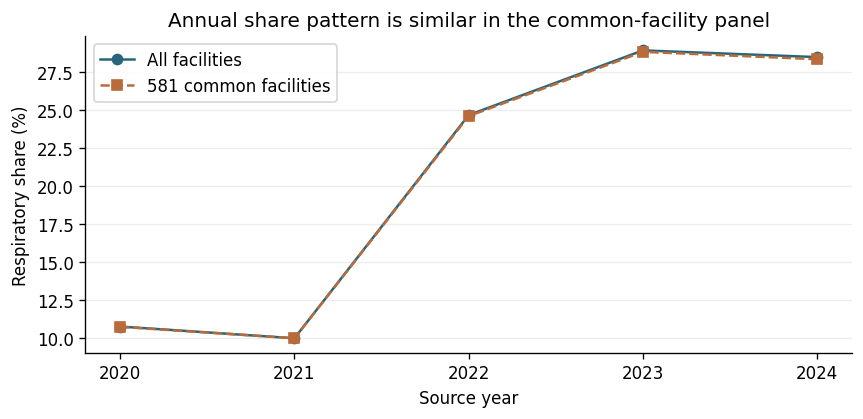

In [11]:
all_rows = clean.loc[clean.IdCausa.eq(1)]
days_by_facility = all_rows.groupby(['source_year', 'IdEstablecimiento']).date.nunique()
coverage = days_by_facility.groupby('source_year').agg(
    reporting_facilities='size', median_reporting_days='median',
    tenth_percentile_reporting_days=lambda s: s.quantile(.1),
    facilities_under_100_days=lambda s: int(s.lt(100).sum()),
    facilities_at_least_300_days=lambda s: int(s.ge(300).sum()))
display(coverage)
common = set.intersection(*(set(g.IdEstablecimiento) for _, g in all_rows.groupby('source_year')))
stable = clean.loc[clean.IdEstablecimiento.isin(common)].groupby(
    ['source_year', 'IdCausa']).Total.sum().unstack()
sensitivity = pd.DataFrame({
    'all_facility_share_pct': 100 * after[2] / after[1],
    'common_facility_share_pct': 100 * stable[2] / stable[1],
    'common_facility_all_visit_coverage_pct': 100 * stable[1] / after[1],
})
display(sensitivity.round(2))
print('Facility IDs appearing all five years:', len(common))
fig, ax = plt.subplots(figsize=(7.3, 3.6))
ax.plot(sensitivity.index, sensitivity.all_facility_share_pct, marker='o', label='All facilities', color='#27667a')
ax.plot(sensitivity.index, sensitivity.common_facility_share_pct, marker='s', ls='--',
        label=f'{len(common)} common facilities', color='#ba6b3b')
ax.set(xlabel='Source year', ylabel='Respiratory share (%)',
       title='Annual share pattern is similar in the common-facility panel')
ax.set_xticks(sensitivity.index); ax.legend(); ax.grid(axis='y', alpha=.22)
fig.tight_layout(); fig.savefig(FIG / 'common_facility_sensitivity.png', bbox_inches='tight'); plt.show()

## 7. Five Cs, interpretation and continuation

**Clean:** No null key/measure cells, invalid dates, negative values or age-sum mismatches in the reduced case; two identical 2023 duplicate rows removed from derived results; recorded zeros retained. **Consistent:** Cause 1/2 and age columns have the same analytical meaning across the included archives, with date-derived weeks correcting boundary-label collisions. **Conformed:** Annual files are combined under common code/field definitions; no external join is claimed. **Current:** The 2020-2024 series supports history, not live 2026 staffing decisions. **Comprehensive:** All local years and dates for the selected codes are included, but the series excludes unrecorded care, patient identity, residence, staffing, beds and outcomes.

**Observation:** Annual respiratory shares were near 10% in 2020-2021 and about 25-29% in 2022-2024; complete-week volume peaks in 2023 and 2024 occurred in May. **Interpretation:** proposed winter planners should monitor before midwinter and compare settings and coverage. **Hypotheses only:** changes in viruses, care seeking, pandemic controls and reporting may contribute. The administrative counts cannot assign causal credit or demonstrate population risk or capacity pressure.

**Future ML feasibility:** A possible two-week-ahead weekly respiratory-visit forecast would use only lags, calendar information and any genuinely available contemporaneous inputs. It needs a current feed and a careful treatment of pandemic-era regime changes. No model is trained for C1. **Future dashboard:** a proposed planner view would show weekly volume/share, historical bands, age and care-setting mix, plus freshness/coverage flags. It would prompt human review rather than prescribe staffing or beds. No finished dashboard is required for C1.

Sources: [DEIS FAQ](https://deis.minsal.cl/faqs/); [MINSAL National Health Strategy 2022](https://www.minsal.cl/wp-content/uploads/2022/03/Estrategia-Nacional-de-Salud-2022-MINSAL-V8.pdf); [MINSAL 2024 Winter Campaign reports](https://www.minsal.cl/campana-invierno-2024-informe-de-virus-respiratorios/); [ISP 2024 virus surveillance](https://www.ispch.cl/biomedico/vigilancia-de-laboratorio/ambitos-de-vigilancia/vigilancia-virus-respiratorios/informes-virus-respiratorios/?y=2024). The full citation and process discussion is in the report PDF.